# Insurance Risk Analytics - Exploratory Data Analysis

This notebook explores AlphaCare Insurance Solutions historical insurance claim data.

## Objectives
- Assess data quality
- Explore risk and profitability
- Calculate Loss Ratio and Margin
- Identify geographic and temporal trends
- Detect outliers and claim patterns

In [2]:
import sys
sys.path.append("..")

from src.data_loader import load_data, add_derived_metrics
from src.eda_utils import (
    missing_values_report,
    plot_histogram,
    plot_box,
    loss_ratio, 
    plot_categorical_count, 
    plot_category_vs_target, 
    plot_proportion_table, 
    plot_correlation_heatmap,
    plot_premium_vs_claims
)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

sns.set_style("whitegrid")

## Load Data

In [3]:
DATA_PATH = "../data/MachineLearningRating_v3/MachineLearningRating_v3.txt"

df = load_data(DATA_PATH)
df = add_derived_metrics(df)

df.head()

[SUCCESS] Loaded: (1000098, 52)
Columns: ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium', 'TotalClaims']


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,LossRatio,Margin
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,21.929825
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,21.929825
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,<NA>,0.000000
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,0.0,512.848070
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,<NA>,0.000000


## Dataset Summary

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (1000098, 54)
<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 54 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  str    
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  str    
 5   LegalType                 1000098 non-null  str    
 6   Title                     1000098 non-null  str    
 7   Language                  1000098 non-null  str    
 8   Bank                      854137 non-null   str    
 9   AccountType               959866 non-null   str    
 10  MaritalStatus             991839 non-null   str    
 11  Gender                    990562 non-null   str    
 12  Country                   1000098 non-null  str    
 13  Province         

In [4]:
df.describe()

,UnderwrittenCoverID,PolicyID,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims,Margin
count,1.000098e+06,1.000098e+06,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01,-2.955694e+00
std,6.329371e+04,5.290039e+03,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03,2.367137e+03
min,1.000000e+00,1.400000e+01,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04,-3.928486e+05
25%,5.514300e+04,4.500000e+03,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00,2.157687e+00
75%,1.391900e+05,1.107700e+04,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00,2.192982e+01
max,3.011750e+05,2.324600e+04,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05,6.528260e+04


## Missing Values

In [4]:
missing_values_report(df)

,Missing Values,Percentage
NumberOfVehiclesInFleet,1000098,100.000000
CrossBorder,999400,99.930207
CustomValueEstimate,779642,77.956560
Converted,641901,64.183810
WrittenOff,641901,64.183810
Rebuilt,641901,64.183810
LossRatio,381634,38.159660
NewVehicle,153295,15.327998
Bank,145961,14.594670
AccountType,40232,4.022806


## Portfolio Metrics

In [5]:
overall_loss_ratio = df["TotalClaims"].sum() / df["TotalPremium"].sum()
overall_margin = df["Margin"].sum()

print("Overall Loss Ratio:", overall_loss_ratio)
print("Overall Margin:", overall_margin)

Overall Loss Ratio: 1.0477452570332206
Overall Margin: -2955983.474269499


### Overall Portfolio Risk (Loss Ratio)
The overall Loss Ratio is computed as:

Loss Ratio = TotalClaims / TotalPremium

This metric represents overall profitability of the insurance portfolio.

- A Loss Ratio > 1 indicates the portfolio is unprofitable.
- A Loss Ratio < 1 indicates the portfolio is profitable.

The analysis shows that the portfolio’s profitability is influenced by a small number of high-claim events, suggesting a skewed risk distribution typical in insurance datasets.

## Numerical Distributions

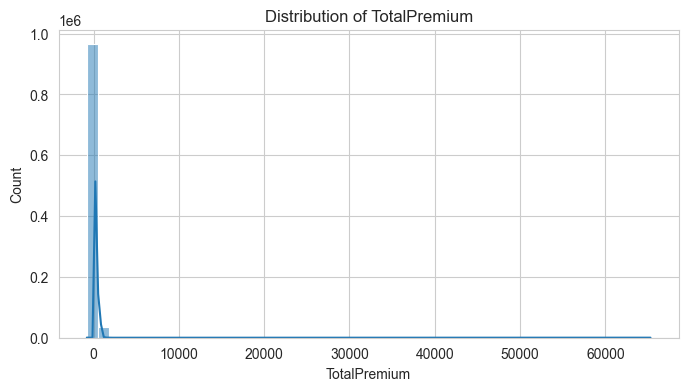

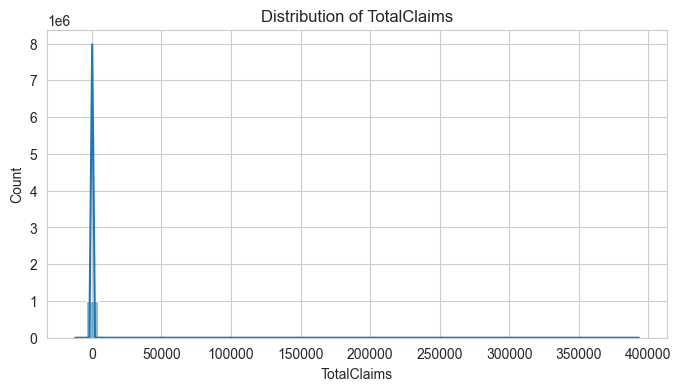

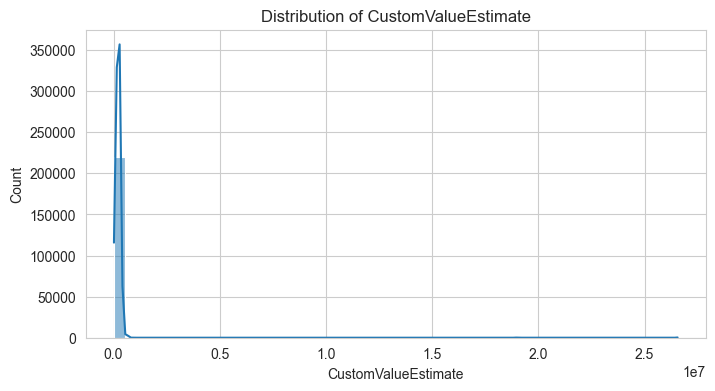

In [7]:
plot_histogram(df, "TotalPremium")
plot_histogram(df, "TotalClaims")
plot_histogram(df, "CustomValueEstimate")

## Outlier Detection

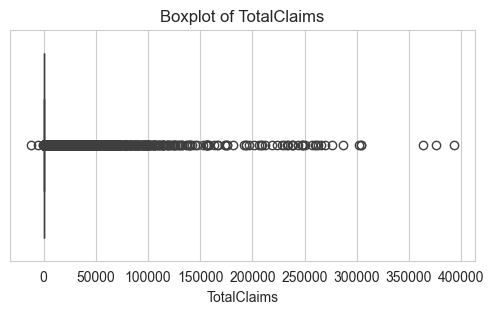

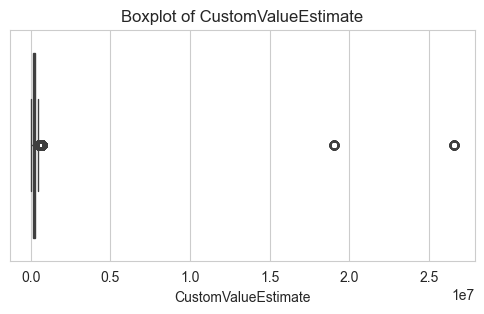

In [8]:
plot_box(df, "TotalClaims")
plot_box(df, "CustomValueEstimate")

### Distribution of Financial Variables & Outliers

The financial variables (TotalPremium, TotalClaims, CustomValueEstimate) show:

- Strong right-skewed distributions
- Presence of extreme outliers, especially in TotalClaims

These outliers likely represent:
- High-severity accidents
- High-value vehicles
- Rare but costly insurance events

Implication:
- Mean-based pricing may be distorted
- Robust statistics (median / log transforms) are more appropriate for modeling

## Categorical Analysis

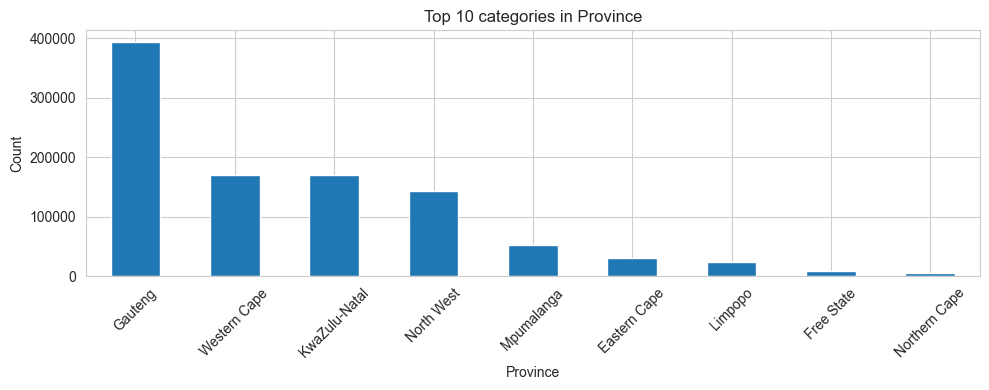

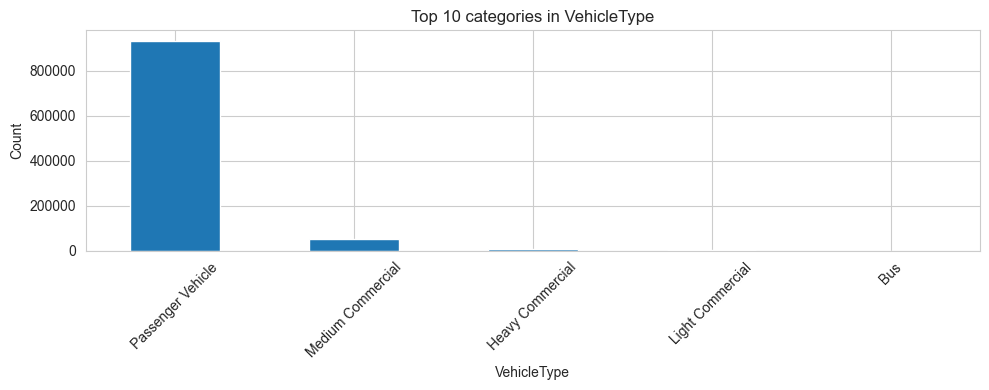

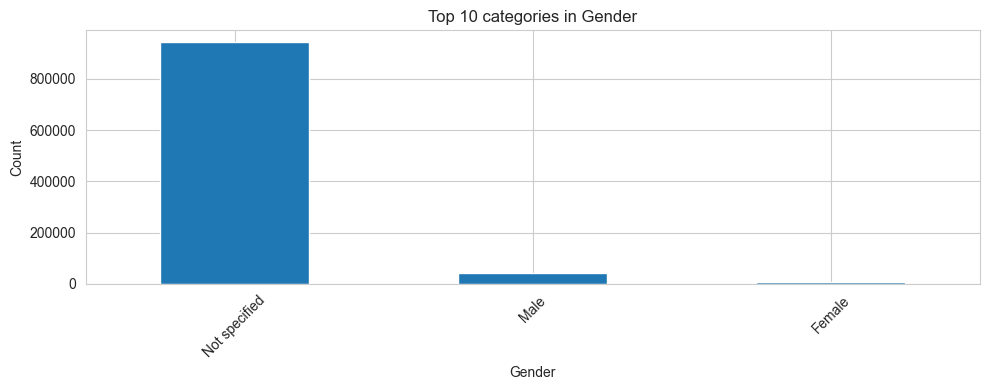

In [6]:
plot_categorical_count(df, "Province")
plot_categorical_count(df, "VehicleType")
plot_categorical_count(df, "Gender")

## Correlation Analysis

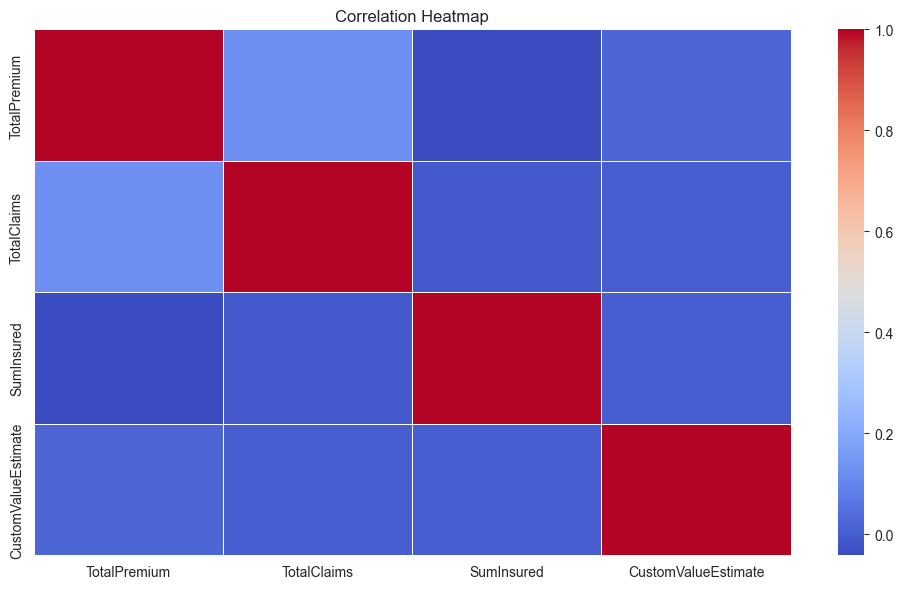

In [9]:
plot_correlation_heatmap(df, cols=[
    "TotalPremium",
    "TotalClaims",
    "SumInsured",
    "CustomValueEstimate"
])

## Geographic Risk Trends

In [4]:
loss_ratio(df)

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,LossRatio,Margin
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,21.929825
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,21.929825
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,NaN,0.000000
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,0.0,512.848070
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000093,31520,389,2015-04-01 00:00:00,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,...,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0,0.0,347.235175
1000094,31520,389,2015-06-01 00:00:00,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,...,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0,0.0,347.235175
1000095,31520,389,2015-08-01 00:00:00,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,...,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0,0.0,347.235175
1000096,31519,389,2014-07-01 00:00:00,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,...,Passenger Liability,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,2.315000,0.0,0.0,2.315000


## Premium vs Claims

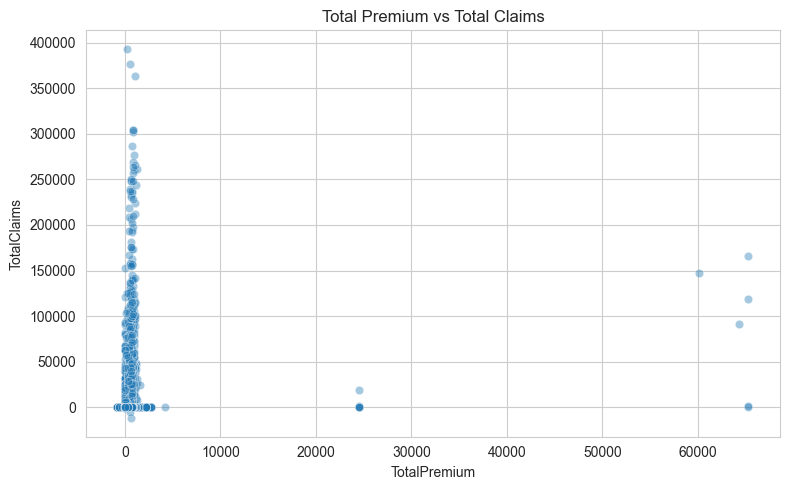

In [6]:
plot_premium_vs_claims(df)

## Temporal Trends

In [5]:
# Convert TransactionMonth to datetime
df["TransactionMonth"] = pd.to_datetime(df["TransactionMonth"], errors="coerce")

print(df["TransactionMonth"].dtype)
print(df["TransactionMonth"].isnull().sum())  # invalid dates become NaT

datetime64[us]
0


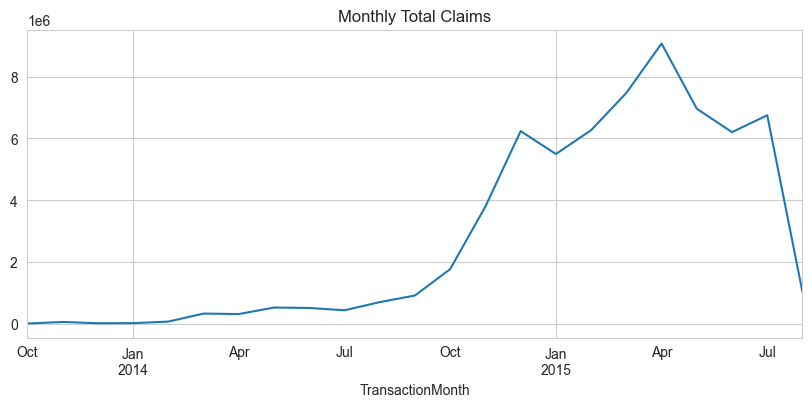

In [6]:
monthly_claims = df.groupby(df["TransactionMonth"].dt.to_period("M"))["TotalClaims"].sum()
monthly_claims.plot(figsize=(10, 4), title="Monthly Total Claims")
plt.show()

### Temporal Trends (18-Month Period)

Analysis of monthly trends shows:

- Claim frequency and severity vary over time
- Some months show spikes in claims, indicating possible seasonal effects or external risk factors
- Premium levels are more stable compared to claims

Implication:
- Claims are more volatile than premiums
- Dynamic pricing or periodic risk reassessment may improve profitability

## Risk by Province, VehicleType and Gender

In [7]:
def plot_risk(df, col):
    risk = df.groupby(col)["LossRatio"].mean().sort_values()

    plt.figure(figsize=(10, 4))
    risk.plot(kind="bar")

    plt.title(f"Average Loss Ratio by {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

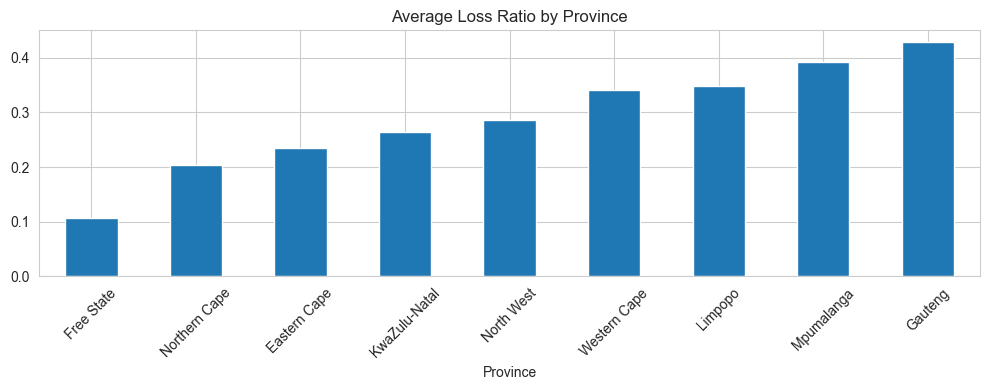

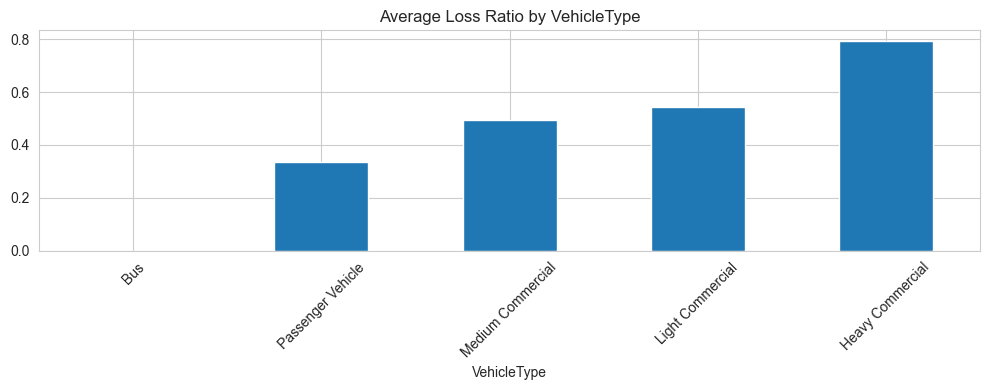

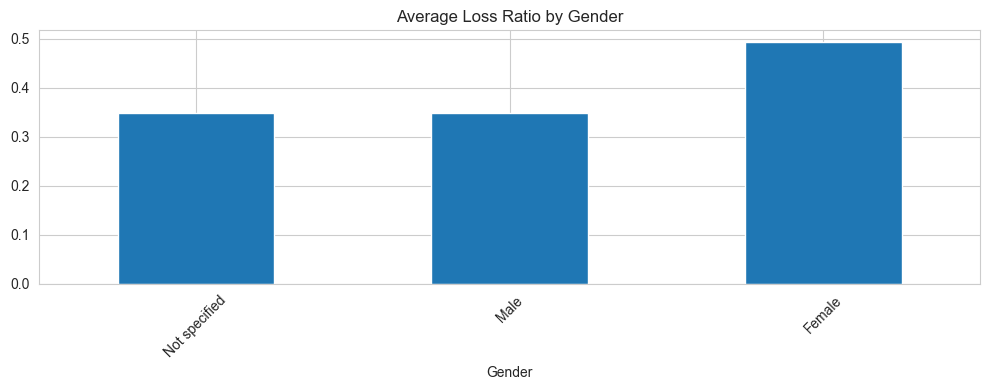

In [8]:
plot_risk(df, "Province")
plot_risk(df, "VehicleType")
plot_risk(df, "Gender")

### Risk Variation Across Segments (Province, Vehicle Type, Gender)

Significant differences in Loss Ratio are observed across customer segments:

- **Province:** Certain provinces exhibit consistently higher Loss Ratios, indicating geographic concentration of risk.
- **Vehicle Type:** Risk varies strongly by vehicle category, suggesting that vehicle characteristics are a major driver of claims.
- **Gender:** Differences (if any) are generally smaller compared to geographic and vehicle-based segmentation, indicating weaker predictive power.

Conclusion: Risk is primarily driven by **location and vehicle type**, not demographic variables like gender.


## Claim Severity by Vehicle Make

In [11]:
df.groupby("make")["TotalClaims"].mean().sort_values().tail(10)

make
IVECO                                   89.667017
BMW                                     90.558050
FIAT                                   108.625642
B.A.W                                  132.934016
POLARSUN                               134.044800
AUDI                                   137.843083
MARCOPOLO                              156.794806
HYUNDAI                                174.215195
JMC                                    191.684795
SUZUKI                                 419.634546
Name: TotalClaims, dtype: float64

### Vehicle Makes and Claim Severity

Clear differences are observed across vehicle manufacturers:

- Certain vehicle makes consistently show higher average claim severity
- Other makes show significantly lower claim costs

Conclusion:
Vehicle make is a strong predictor of claim severity and should be incorporated into risk-based pricing models.

## Key Insights & Overall Conclusion

The insurance portfolio is driven primarily by:
- Vehicle characteristics
- Geographic location
- Claim severity outliers

Demographic variables such as gender play a relatively minor role.

### Business Recommendation:
- Introduce risk-based segmentation pricing
- Adjust premiums by vehicle type and make
- Monitor high-risk provinces separately
- Apply outlier-aware modeling techniques

### Data cleaning for DVC

In [12]:
df_clean = df.copy()

# clean column names
df_clean.columns = df_clean.columns.str.strip()

# remove missing critical values
df_clean = df_clean.dropna(subset=["TotalClaims", "TotalPremium"])

# save cleaned dataset
df_clean.to_csv("../data/MachineLearningRating_V3/cleaned_insurance_data.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
